# UCB Configuration Selection Ã¢â‚¬â€ Thesis

Mirrors `config_selection_thesis.ipynb` for the UCB algorithm.

UCB parameter mapping vs MCTS/MCGS:
- `batch_size` Ã¢â€ â€ `num_rollouts` (candidates scored per step)
- `step_budget` Ã¢â€ â€ `num_evals / desired_length` (total evals Ã¢â€°Ë† `step_budget Ãƒâ€” 30`)
- `ucb_c` Ã¢â€ â€ `c` (exploration constant)
- `ucb_alpha` Ã¢â€ â€ `alpha` (prior weight)

Primary metric: **relative probability drop** $r = (p_{\text{orig}} - p_{\text{masked}}) / p_{\text{orig}}$.

## Setup

In [1]:
import os

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import seaborn as sns


MLFLOW_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
EXPERIMENT_NAME = "ucb-grid-thesis"

os.environ["MLFLOW_TRACKING_USERNAME"] = "YOUR_MLFLOW_USERNAME"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "YOUR_MLFLOW_PASSWORD"

mlflow.set_tracking_uri(MLFLOW_URI)
client = mlflow.MlflowClient()
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

In [2]:
METRIC_COLS = [
    "region_0/probability_drop",
    "region_0/evaluations_count",
    "region_0/original_prob",
    "time_seconds",
]

exp = client.get_experiment_by_name(EXPERIMENT_NAME)
assert exp is not None, f"Experiment '{EXPERIMENT_NAME}' not found."
all_runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id], max_results=10000, output_format="pandas"
)
all_runs["algorithm"] = "ucb"

PARENT_TAG = "tags.mlflow.parentRunId"
child_runs = all_runs[all_runs[PARENT_TAG].notna()].copy()
parent_runs = all_runs[all_runs[PARENT_TAG].isna()].copy()

parent_param_cols = sorted(c for c in parent_runs.columns if c.startswith("params."))
child_runs = child_runs.drop(
    columns=[c for c in parent_param_cols if c in child_runs.columns]
)
child_runs = child_runs.join(
    parent_runs.set_index("run_id")[parent_param_cols], on=PARENT_TAG
)

for col in parent_param_cols:
    if col in child_runs.columns:
        child_runs[col] = pd.to_numeric(child_runs[col], errors="coerce")
for col in [c for c in child_runs.columns if c.startswith("metrics.")]:
    child_runs[col] = pd.to_numeric(child_runs[col], errors="coerce")

child_runs = child_runs[
    ~child_runs["params.method.step_budget"].isin([2000, 5000])
].copy()

child_runs = child_runs.rename(
    columns={
        "params.method.batch_size": "batch_size",
        "params.method.step_budget": "step_budget",
        "params.method.ucb_c": "ucb_c",
        "params.method.ucb_alpha": "ucb_alpha",
        "metrics.region_0/probability_drop": "prob_drop",
        "metrics.region_0/evaluations_count": "evals_used",
        "metrics.region_0/original_prob": "original_prob",
        "metrics.time_seconds": "time_s",
        "tags.mlflow.runName": "image_name",
    }
)
child_runs["rel_drop"] = child_runs["prob_drop"] / child_runs["original_prob"]

needed = [
    "batch_size",
    "step_budget",
    "ucb_c",
    "ucb_alpha",
    "image_name",
    "prob_drop",
    "rel_drop",
    "original_prob",
    "evals_used",
]
child_runs = child_runs.dropna(subset=needed).reset_index(drop=True)

GROUP = ["batch_size", "step_budget", "ucb_c", "ucb_alpha"]
agg = (
    child_runs.groupby(GROUP)[["rel_drop", "prob_drop", "evals_used", "time_s"]]
    .agg(["mean", "std"])
    .reset_index()
)
agg.columns = ["_".join(c).rstrip("_") for c in agg.columns]

print(f"Loaded {len(child_runs)} per-image runs across {len(agg)} configurations.")
print(f"batch_size values : {sorted(child_runs['batch_size'].unique())}")
print(f"step_budget values: {sorted(child_runs['step_budget'].unique())}")
print(f"ucb_c values      : {sorted(child_runs['ucb_c'].unique())}")
print(f"ucb_alpha values  : {sorted(child_runs['ucb_alpha'].unique())}")

Loaded 1350 per-image runs across 45 configurations.
batch_size values : [np.float64(1.0), np.float64(16.0), np.float64(64.0)]
step_budget values: [np.float64(300.0), np.float64(2767.0), np.float64(3333.0)]
ucb_c values      : [np.float64(0.1), np.float64(0.7), np.float64(1.4), np.float64(3.0), np.float64(5.0)]
ucb_alpha values  : [np.float64(0.0), np.float64(0.5), np.float64(1.0)]


## Quick sanity check Ã¢â‚¬â€ eval counts and wall times

Verify that the calibrated `(batch_size, step_budget)` tiers actually produce eval counts and wall times comparable to the MCTS/MCGS grid (target: ~9k / ~83k / ~100k evals, Ã¢â€°Â¤30s).

In [3]:
tier_summary = (
    agg.groupby(["batch_size", "step_budget"])[["evals_used_mean", "time_s_mean"]]
    .mean()
    .reset_index()
    .sort_values("batch_size")
)
tier_summary["evals_used_mean"] = tier_summary["evals_used_mean"].round(0).astype(int)
tier_summary["time_s_mean"] = tier_summary["time_s_mean"].round(1)
print(
    "Mean evals and wall time per (batch_size, step_budget) tier (averaged over ucb_c, ucb_alpha):"
)
print(tier_summary.to_string(index=False))

Mean evals and wall time per (batch_size, step_budget) tier (averaged over ucb_c, ucb_alpha):
 batch_size  step_budget  evals_used_mean  time_s_mean
        1.0        300.0             8313         26.3
       16.0       2767.0            74186         27.6
       64.0       3333.0            89152         27.7


## Effect of `batch_size` (analogue of `num_rollouts`)

`batch_size` controls how many candidate segments are scored per UCB step. Larger values provide better estimates per step but consume more evaluations per step.

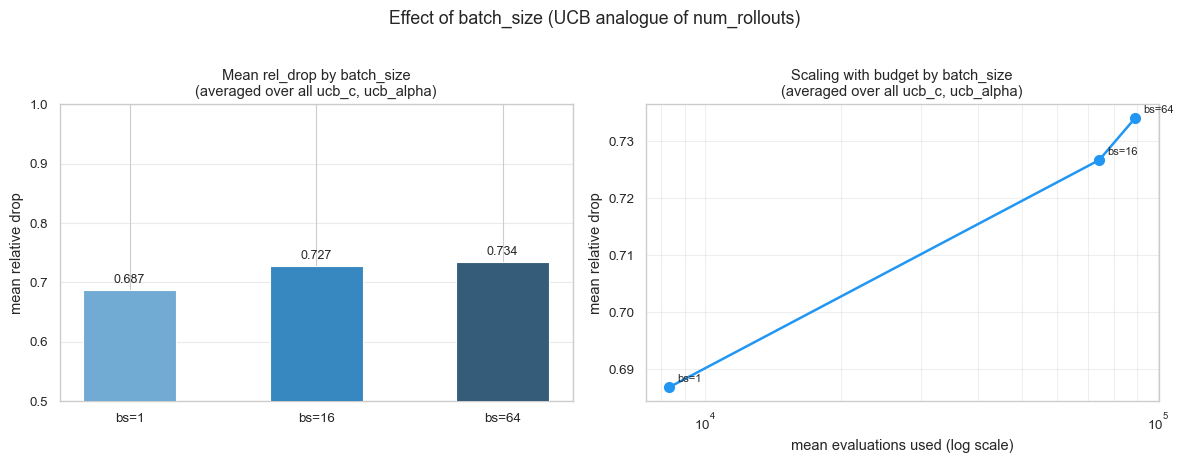

In [4]:
bs_vals = sorted(agg["batch_size"].unique())
bs_palette = sns.color_palette("Blues_d", n_colors=len(bs_vals))
bs_to_color = dict(zip(bs_vals, bs_palette, strict=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: mean rel_drop per batch_size, averaged over (ucb_c, ucb_alpha)
ax = axes[0]
means = agg.groupby("batch_size")["rel_drop_mean"].mean().reindex(bs_vals)
bars = ax.bar(
    [f"bs={int(b)}" for b in bs_vals],
    means.values,
    color=[bs_to_color[b] for b in bs_vals],
    width=0.5,
    zorder=3,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylabel("mean relative drop")
ax.set_title("Mean rel_drop by batch_size\n(averaged over all ucb_c, ucb_alpha)")
ax.set_ylim(0.5, 1.0)
ax.grid(axis="y", alpha=0.4)

# Right: scaling curve Ã¢â‚¬â€ rel_drop vs evals, one point per batch_size tier
ax = axes[1]
tier_means = (
    agg.groupby(["batch_size", "step_budget"])
    .agg(
        evals=pd.NamedAgg("evals_used_mean", "mean"),
        rel_drop=pd.NamedAgg("rel_drop_mean", "mean"),
    )
    .reset_index()
    .sort_values("evals")
)
ax.plot(
    tier_means["evals"],
    tier_means["rel_drop"],
    marker="o",
    linewidth=1.8,
    markersize=7,
    color="#2196F3",
)
for _, row in tier_means.iterrows():
    ax.annotate(
        f"bs={int(row['batch_size'])}",
        (row["evals"], row["rel_drop"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )
ax.set_xscale("log")
ax.set_xlabel("mean evaluations used (log scale)")
ax.set_ylabel("mean relative drop")
ax.set_title("Scaling with budget by batch_size\n(averaged over all ucb_c, ucb_alpha)")
ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Effect of batch_size (UCB analogue of num_rollouts)", y=1.02)
fig.tight_layout()
plt.show()

## Effect of `ucb_c` (exploration constant)

Same role as `c` in MCTS/MCGS: controls the UCB exploration bonus. We test $c \in \{0.1, 0.7, 1.4, 3.0, 5.0\}$.

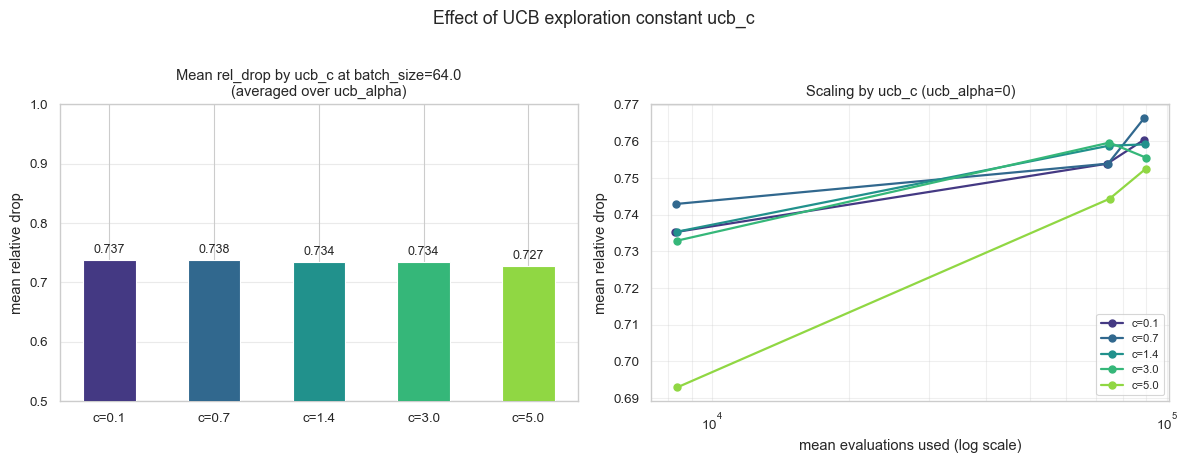

In [5]:
c_vals = sorted(agg["ucb_c"].unique())
c_palette = sns.color_palette("viridis", n_colors=len(c_vals))
c_to_color = dict(zip(c_vals, c_palette, strict=False))

# Use the highest batch_size tier for the bar chart
max_bs = max(bs_vals)
top_tier = agg[agg["batch_size"] == max_bs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: mean rel_drop per ucb_c at highest batch_size, averaged over ucb_alpha
ax = axes[0]
means = top_tier.groupby("ucb_c")["rel_drop_mean"].mean().reindex(c_vals)
bars = ax.bar(
    [f"c={c}" for c in c_vals],
    means.values,
    color=[c_to_color[c] for c in c_vals],
    width=0.5,
    zorder=3,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylabel("mean relative drop")
ax.set_title(
    f"Mean rel_drop by ucb_c at batch_size={max_bs}\n(averaged over ucb_alpha)"
)
ax.set_ylim(0.5, 1.0)
ax.grid(axis="y", alpha=0.4)

# Right: scaling curves per ucb_c, ucb_alpha=0
ax = axes[1]
sub = agg[agg["ucb_alpha"] == 0.0].sort_values("evals_used_mean")
for c_val, grp in sub.groupby("ucb_c"):
    grp = grp.sort_values("evals_used_mean")
    ax.plot(
        grp["evals_used_mean"],
        grp["rel_drop_mean"],
        color=c_to_color[c_val],
        marker="o",
        markersize=5,
        linewidth=1.6,
        label=f"c={c_val}",
    )
ax.set_xscale("log")
ax.set_xlabel("mean evaluations used (log scale)")
ax.set_ylabel("mean relative drop")
ax.set_title("Scaling by ucb_c (ucb_alpha=0)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Effect of UCB exploration constant ucb_c", y=1.02)
fig.tight_layout()
plt.show()

## Effect of `ucb_alpha` (prior weight)

Same role as `alpha` in MCTS/MCGS: weights a prior over which segments to visit. We test $\alpha \in \{0.0, 0.5, 1.0\}$.

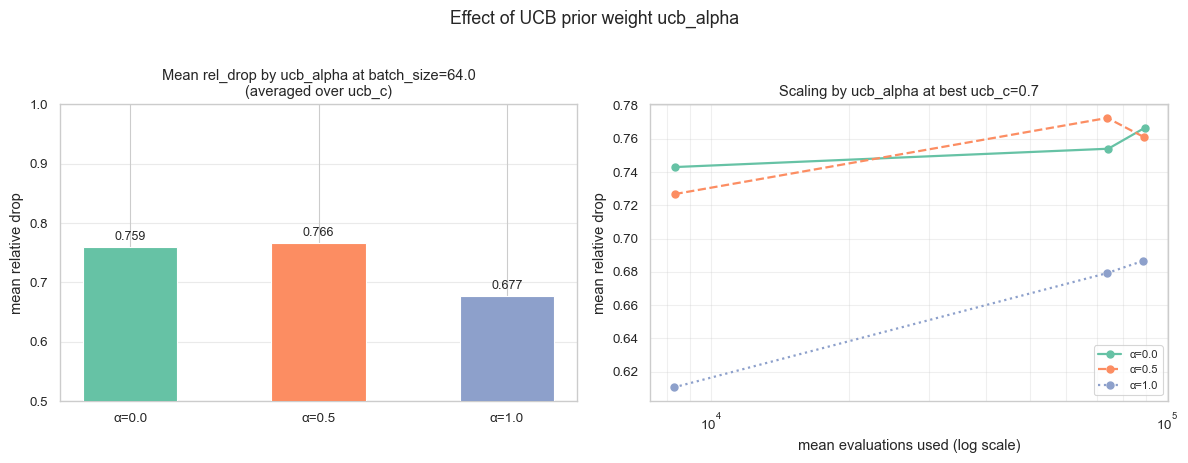

In [6]:
a_vals = sorted(agg["ucb_alpha"].unique())
a_palette = sns.color_palette("Set2", n_colors=len(a_vals))
a_to_color = dict(zip(a_vals, a_palette, strict=False))
alpha_to_ls = {0.0: "-", 0.5: "--", 1.0: ":"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: mean rel_drop per ucb_alpha at highest batch_size, averaged over ucb_c
ax = axes[0]
means = top_tier.groupby("ucb_alpha")["rel_drop_mean"].mean().reindex(a_vals)
bars = ax.bar(
    [f"ÃŽÂ±={a}" for a in a_vals],
    means.values,
    color=[a_to_color[a] for a in a_vals],
    width=0.5,
    zorder=3,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylabel("mean relative drop")
ax.set_title(
    f"Mean rel_drop by ucb_alpha at batch_size={max_bs}\n(averaged over ucb_c)"
)
ax.set_ylim(0.5, 1.0)
ax.grid(axis="y", alpha=0.4)

# Right: scaling curves per ucb_alpha, at the best ucb_c (determined from previous section)
# We pick the ucb_c with highest mean rel_drop at the top tier
best_c = top_tier.groupby("ucb_c")["rel_drop_mean"].mean().idxmax()
sub = agg[agg["ucb_c"] == best_c].sort_values("evals_used_mean")
ax = axes[1]
for a_val, grp in sub.groupby("ucb_alpha"):
    grp = grp.sort_values("evals_used_mean")
    ax.plot(
        grp["evals_used_mean"],
        grp["rel_drop_mean"],
        color=a_to_color[a_val],
        linestyle=alpha_to_ls.get(a_val, "-"),
        marker="o",
        markersize=5,
        linewidth=1.6,
        label=f"ÃŽÂ±={a_val}",
    )
ax.set_xscale("log")
ax.set_xlabel("mean evaluations used (log scale)")
ax.set_ylabel("mean relative drop")
ax.set_title(f"Scaling by ucb_alpha at best ucb_c={best_c}")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Effect of UCB prior weight ucb_alpha", y=1.02)
fig.tight_layout()
plt.show()

## Best configuration summary

Rank all configurations at the highest batch_size tier by mean rel_drop.

In [7]:
top = top_tier.sort_values("rel_drop_mean", ascending=False).reset_index(drop=True)
print(f"Top 10 UCB configurations at batch_size={max_bs}, sorted by mean rel_drop:")
print(
    top[
        [
            "batch_size",
            "step_budget",
            "ucb_c",
            "ucb_alpha",
            "rel_drop_mean",
            "rel_drop_std",
            "evals_used_mean",
            "time_s_mean",
        ]
    ]
    .head(10)
    .round(3)
    .to_string(index=False)
)

best = top.iloc[0]
print("\nRecommended UCB configuration:")
print(f"  batch_size = {int(best['batch_size'])}")
print(f"  step_budget = {int(best['step_budget'])}")
print(f"  ucb_c = {best['ucb_c']}")
print(f"  ucb_alpha = {best['ucb_alpha']}")
print(f"  rel_drop_mean = {best['rel_drop_mean']:.4f}")
print(f"  evals_used_mean Ã¢â€°Ë† {int(best['evals_used_mean'])}")
print(f"  time_s_mean Ã¢â€°Ë† {best['time_s_mean']:.1f}s")

Top 10 UCB configurations at batch_size=64.0, sorted by mean rel_drop:
 batch_size  step_budget  ucb_c  ucb_alpha  rel_drop_mean  rel_drop_std  evals_used_mean  time_s_mean
       64.0       3333.0    1.4        0.5          0.776         0.334        89241.833       27.774
       64.0       3333.0    0.1        0.5          0.769         0.338        88306.667       27.547
       64.0       3333.0    0.7        0.0          0.766         0.335        89203.467       27.824
       64.0       3333.0    5.0        0.5          0.766         0.335        89844.300       27.926
       64.0       3333.0    0.7        0.5          0.761         0.344        88842.367       27.680
       64.0       3333.0    0.1        0.0          0.760         0.338        89019.967       27.992
       64.0       3333.0    1.4        0.0          0.759         0.342        89580.567       27.994
       64.0       3333.0    3.0        0.5          0.759         0.338        89592.867       27.764
       64.0

## Per-image normalized scores & win counts

For each image, `rel_drop` is normalized to [0, 1] across all configs for that image (0 = worst, 1 = best). This mirrors the metric used in `compare_algorithms_imagenet_s`.

**Win counting:** for each image, the config with the highest normalized score wins. Two variants: no threshold (all images produce a winner) and a decisive-margin threshold (winner must exceed 2nd place by at least `WIN_MARGIN`).

Results are shown for all configs combined (table) and for the highest-budget tier `batch_size=max_bs` (bar charts).

In [8]:
WIN_MARGIN = 0.05  # minimum normalized-score gap for a decisive win


def _add_norm_scores(df):
    def _norm(grp):
        mn, mx = grp["prob_drop"].min(), grp["prob_drop"].max()
        grp = grp.copy()
        grp["norm_score"] = 0.5 if mx == mn else (grp["prob_drop"] - mn) / (mx - mn)
        return grp

    return df.groupby("image_name", group_keys=False).apply(_norm)


def _count_wins_ucb(df, margin):
    _G = ["batch_size", "step_budget", "ucb_c", "ucb_alpha"]
    records = []
    for _, grp in df.groupby("image_name"):
        valid = grp.dropna(subset=["norm_score"])
        if len(valid) < 2:
            continue
        ranked = valid.nlargest(len(valid), "norm_score")
        if (
            margin == 0.0
            or (ranked.iloc[0]["norm_score"] - ranked.iloc[1]["norm_score"]) > margin
        ):
            records.append(ranked.iloc[0][_G].to_dict())
    if not records:
        return pd.DataFrame(columns=_G + ["wins"])
    rec = pd.DataFrame(records)
    return rec.groupby(_G).size().reset_index(name="wins")


import numpy as np


_GROUP = ["batch_size", "step_budget", "ucb_c", "ucb_alpha"]
child_runs_n = _add_norm_scores(child_runs)


_wins_no = _count_wins_ucb(child_runs_n, 0.0)
_wins_mg = _count_wins_ucb(child_runs_n, WIN_MARGIN)


norm_sum = (
    child_runs_n.groupby(_GROUP)["norm_score"]
    .agg(norm_score_mean="mean", norm_score_std="std")
    .reset_index()
    .merge(_wins_no.rename(columns={"wins": "wins_no_margin"}), on=_GROUP, how="left")
    .merge(_wins_mg.rename(columns={"wins": "wins_decisive"}), on=_GROUP, how="left")
    .fillna({"wins_no_margin": 0, "wins_decisive": 0})
    .sort_values("norm_score_mean", ascending=False)
    .reset_index(drop=True)
)
norm_sum[["wins_no_margin", "wins_decisive"]] = norm_sum[
    ["wins_no_margin", "wins_decisive"]
].astype(int)

_n_img = child_runs_n["image_name"].nunique()
_n_dec = int(_wins_mg["wins"].sum()) if not _wins_mg.empty else 0
print(
    f"Total images: {_n_img}  |  Decisive winners (margin={WIN_MARGIN}): {_n_dec}/{_n_img}"
)
print("\nTop 15 configs by mean normalized per-image score:")
display(norm_sum.head(15).round(4))


# Mean rank per image (non-parametric)
def _add_ranks(df):
    def _rank(grp):
        grp = grp.copy()
        grp["rank"] = grp["prob_drop"].rank(method="average", ascending=False)
        return grp

    return df.groupby("image_name", group_keys=False).apply(_rank)


ranked = _add_ranks(child_runs_n)


rank_sum = (
    ranked.groupby(_GROUP)["rank"]
    .agg(mean_rank="mean", rank_std="std", n_images="count")
    .reset_index()
    .sort_values("mean_rank")
    .reset_index(drop=True)
)
print("\nTop 15 configs by mean per-image rank (lower is better):")
display(rank_sum.head(15).round(3))

# Combined ranking across metrics
prob_stats = agg[_GROUP + ["prob_drop_mean", "prob_drop_std"]].copy()
norm_stats = norm_sum[_GROUP + ["norm_score_mean", "norm_score_std"]].copy()
rank_stats = rank_sum[_GROUP + ["mean_rank", "rank_std"]].copy()

combined = prob_stats.merge(norm_stats, on=_GROUP, how="inner").merge(
    rank_stats, on=_GROUP, how="inner"
)
combined["rank_prob_drop"] = (
    combined["prob_drop_mean"].rank(ascending=False, method="min").astype(int)
)
combined["rank_norm_score"] = (
    combined["norm_score_mean"].rank(ascending=False, method="min").astype(int)
)
combined["rank_mean_rank"] = (
    combined["mean_rank"].rank(ascending=True, method="min").astype(int)
)
combined["final_score"] = combined[
    ["rank_prob_drop", "rank_norm_score", "rank_mean_rank"]
].mean(axis=1)


def _fmt_mean_std(mean, std):
    return f"{mean:.4f} +/- {std:.4f}"


out = combined.copy()
out["algorithm"] = "ucb"
out["batch_size"] = out["batch_size"].astype(int)
out["step_budget"] = out["step_budget"].astype(int)
out["prob_drop"] = out.apply(
    lambda r: _fmt_mean_std(r["prob_drop_mean"], r["prob_drop_std"]), axis=1
)
out["norm_score"] = out.apply(
    lambda r: _fmt_mean_std(r["norm_score_mean"], r["norm_score_std"]), axis=1
)
out["mean_rank"] = out.apply(
    lambda r: _fmt_mean_std(r["mean_rank"], r["rank_std"]), axis=1
)
out["final_score"] = out["final_score"].round(3)

top10 = (
    out[
        [
            "algorithm",
            "batch_size",
            "step_budget",
            "ucb_c",
            "ucb_alpha",
            "prob_drop",
            "rank_prob_drop",
            "norm_score",
            "rank_norm_score",
            "mean_rank",
            "rank_mean_rank",
            "final_score",
        ]
    ]
    .sort_values("final_score")
    .head(10)
    .reset_index(drop=True)
)
display(top10)

Total images: 30  |  Decisive winners (margin=0.05): 4/30

Top 15 configs by mean normalized per-image score:


TEMP_DIR/ipykernel_31948\4286488128.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("image_name", group_keys=False).apply(_norm)


,batch_size,step_budget,ucb_c,ucb_alpha,norm_score_mean,norm_score_std,wins_no_margin,wins_decisive
0,64.0,3333.0,1.4,0.5,0.8832,0.1950,6,2
1,16.0,2767.0,0.7,0.5,0.8735,0.1618,1,0
2,64.0,3333.0,0.1,0.5,0.8688,0.1912,2,1
3,64.0,3333.0,5.0,0.5,0.8670,0.1421,2,0
4,64.0,3333.0,0.1,0.0,0.8603,0.1796,0,0
5,16.0,2767.0,0.1,0.5,0.8553,0.1928,2,0
6,64.0,3333.0,3.0,0.5,0.8534,0.1684,2,0
7,16.0,2767.0,0.1,0.0,0.8517,0.1850,2,0
8,64.0,3333.0,3.0,0.0,0.8514,0.2017,1,0
9,64.0,3333.0,0.7,0.0,0.8473,0.1547,1,0



Top 15 configs by mean per-image rank (lower is better):


TEMP_DIR/ipykernel_31948\4286488128.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("image_name", group_keys=False).apply(_rank)


,batch_size,step_budget,ucb_c,ucb_alpha,mean_rank,rank_std,n_images
0,64.0,3333.0,5.0,0.5,10.133,6.522,30
1,16.0,2767.0,0.7,0.5,10.267,6.458,30
2,64.0,3333.0,1.4,0.5,10.817,9.553,30
3,64.0,3333.0,0.1,0.5,10.950,8.357,30
4,16.0,2767.0,0.1,0.0,11.617,8.086,30
5,64.0,3333.0,3.0,0.5,12.150,7.658,30
6,16.0,2767.0,0.1,0.5,12.633,8.165,30
7,64.0,3333.0,0.7,0.0,12.867,8.281,30
8,64.0,3333.0,3.0,0.0,13.117,8.380,30
9,16.0,2767.0,1.4,0.5,13.467,8.692,30


,algorithm,batch_size,step_budget,ucb_c,ucb_alpha,prob_drop,rank_prob_drop,norm_score,rank_norm_score,mean_rank,rank_mean_rank,final_score
0,ucb,64,3333,1.4,0.5,0.6260 +/- 0.3006,1,0.8832 +/- 0.1950,1,10.8167 +/- 9.5534,3,1.667
1,ucb,16,2767,0.7,0.5,0.6233 +/- 0.3023,2,0.8735 +/- 0.1618,2,10.2667 +/- 6.4577,2,2.000
2,ucb,64,3333,5.0,0.5,0.6167 +/- 0.2996,5,0.8670 +/- 0.1421,4,10.1333 +/- 6.5218,1,3.333
3,ucb,64,3333,0.1,0.5,0.6191 +/- 0.3029,3,0.8688 +/- 0.1912,3,10.9500 +/- 8.3567,4,3.333
4,ucb,16,2767,0.1,0.5,0.6151 +/- 0.3043,6,0.8553 +/- 0.1928,6,12.6333 +/- 8.1652,7,6.333
5,ucb,64,3333,0.7,0.0,0.6176 +/- 0.2995,4,0.8473 +/- 0.1547,10,12.8667 +/- 8.2806,8,7.333
6,ucb,64,3333,3.0,0.5,0.6098 +/- 0.2986,12,0.8534 +/- 0.1684,7,12.1500 +/- 7.6577,6,8.333
7,ucb,64,3333,0.1,0.0,0.6114 +/- 0.2990,8,0.8603 +/- 0.1796,5,14.1333 +/- 7.8300,12,8.333
8,ucb,16,2767,0.1,0.0,0.6038 +/- 0.3046,19,0.8517 +/- 0.1850,8,11.6167 +/- 8.0865,5,10.667
9,ucb,64,3333,3.0,0.0,0.6065 +/- 0.3050,16,0.8514 +/- 0.2017,9,13.1167 +/- 8.3797,9,11.333


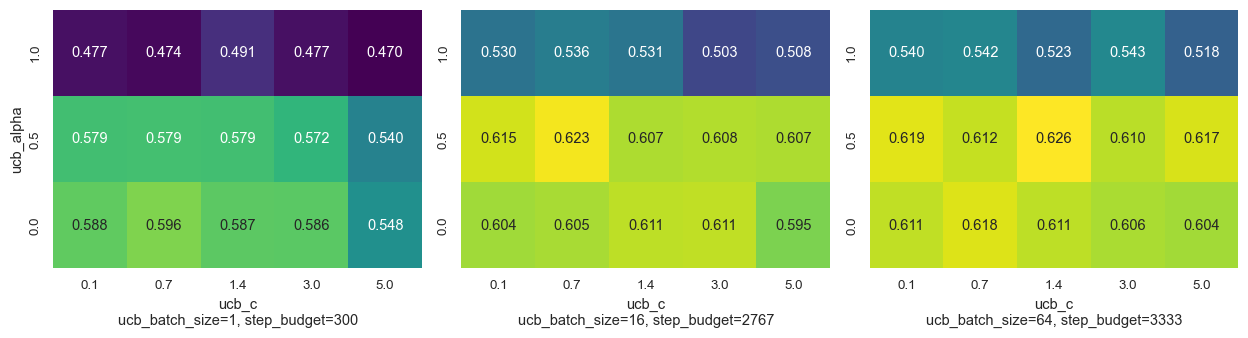

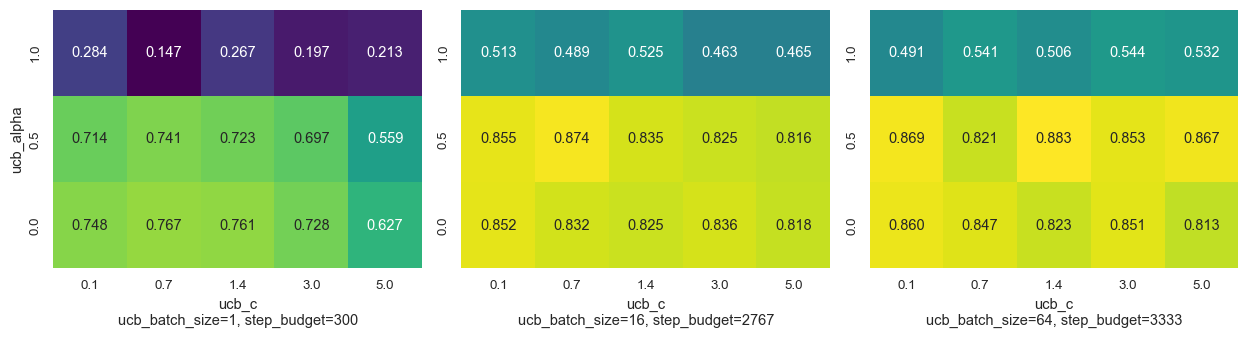

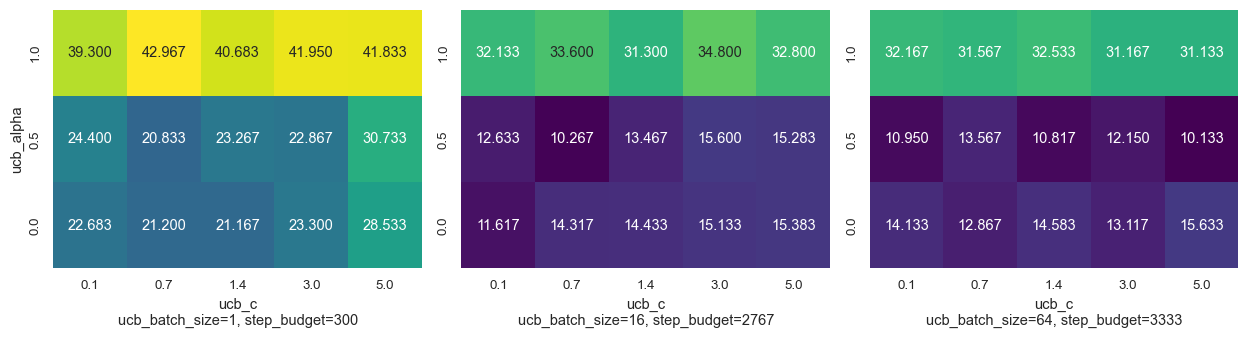

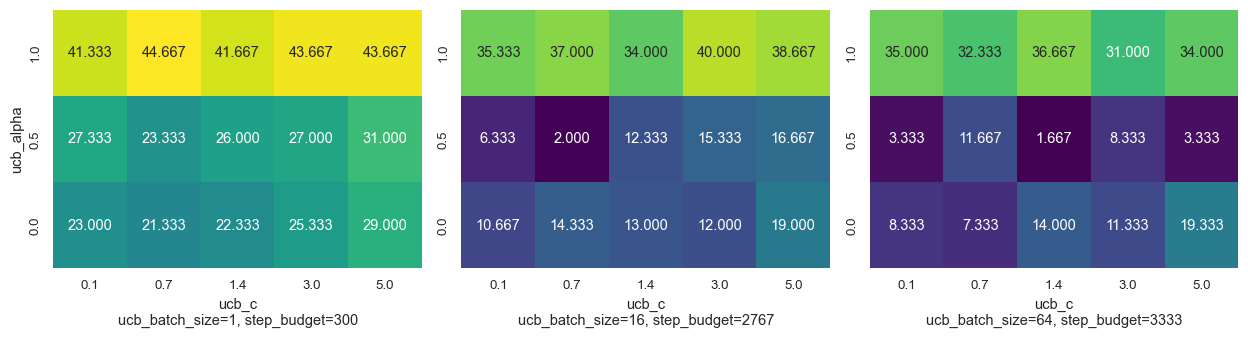

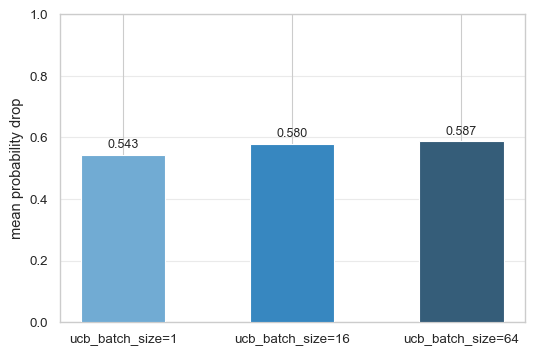

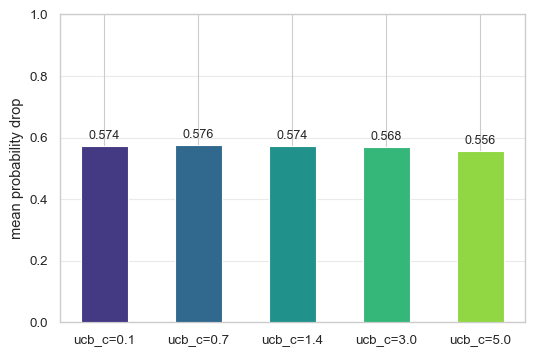

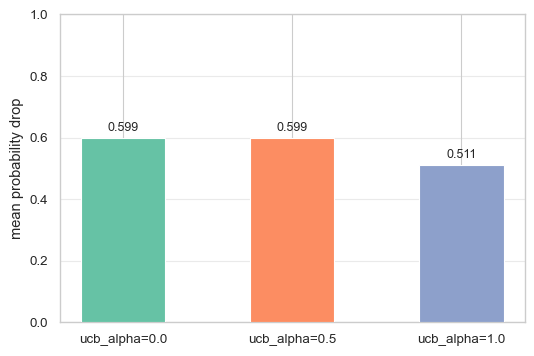

In [9]:
def plot_heatmap_grid(df: pd.DataFrame, value: str) -> None:
    pairs = df[["batch_size", "step_budget"]].dropna().drop_duplicates()
    pairs = pairs.sort_values(["batch_size", "step_budget"])
    pairs = list(pairs.itertuples(index=False, name=None))
    if not pairs:
        return
    n_pairs = len(pairs)
    ncols = min(3, n_pairs)
    nrows = (n_pairs + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 3.5 * nrows),
        squeeze=False,
    )
    vmin, vmax = df[value].min(), df[value].max()
    for idx, (bs, sb) in enumerate(pairs):
        i, j = divmod(idx, ncols)
        ax = axes[i][j]
        sub = df[(df["batch_size"] == bs) & (df["step_budget"] == sb)]
        pivot = sub.pivot_table(
            index="ucb_alpha", columns="ucb_c", values=value, aggfunc="mean"
        )
        sns.heatmap(
            pivot,
            ax=ax,
            annot=True,
            fmt=".3f",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            cbar=False,
        )
        ax.invert_yaxis()
        if j == 0:
            ax.set_ylabel("ucb_alpha")
        else:
            ax.set_ylabel("")
        ax.set_xlabel(f"ucb_c\nucb_batch_size={int(bs)}, step_budget={int(sb)}")
    for idx in range(n_pairs, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_axis_off()
    fig.tight_layout()
    plt.show()


plot_heatmap_grid(agg, "prob_drop_mean")
plot_heatmap_grid(norm_sum, "norm_score_mean")
plot_heatmap_grid(rank_sum, "mean_rank")
plot_heatmap_grid(combined, "final_score")

# Mean prob_drop bar charts (left panels)
bs_vals = sorted(agg["batch_size"].unique())
bs_palette = sns.color_palette("Blues_d", n_colors=len(bs_vals))
bs_to_color = dict(zip(bs_vals, bs_palette, strict=False))
fig, ax = plt.subplots(figsize=(6, 4))
means = agg.groupby("batch_size")["prob_drop_mean"].mean().reindex(bs_vals)
bars = ax.bar(
    [f"ucb_batch_size={int(b)}" for b in bs_vals],
    means.values,
    color=[bs_to_color[b] for b in bs_vals],
    width=0.5,
    zorder=3,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylabel("mean probability drop")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.4)
plt.show()

c_vals = sorted(agg["ucb_c"].unique())
c_palette = sns.color_palette("viridis", n_colors=len(c_vals))
c_to_color = dict(zip(c_vals, c_palette, strict=False))
fig, ax = plt.subplots(figsize=(6, 4))
means = agg.groupby("ucb_c")["prob_drop_mean"].mean().reindex(c_vals)
bars = ax.bar(
    [f"ucb_c={c}" for c in c_vals],
    means.values,
    color=[c_to_color[c] for c in c_vals],
    width=0.5,
    zorder=3,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylabel("mean probability drop")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.4)
plt.show()

a_vals = sorted(agg["ucb_alpha"].unique())
a_palette = sns.color_palette("Set2", n_colors=len(a_vals))
a_to_color = dict(zip(a_vals, a_palette, strict=False))
fig, ax = plt.subplots(figsize=(6, 4))
means = agg.groupby("ucb_alpha")["prob_drop_mean"].mean().reindex(a_vals)
bars = ax.bar(
    [f"ucb_alpha={a}" for a in a_vals],
    means.values,
    color=[a_to_color[a] for a in a_vals],
    width=0.5,
    zorder=3,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylabel("mean probability drop")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.4)
plt.show()

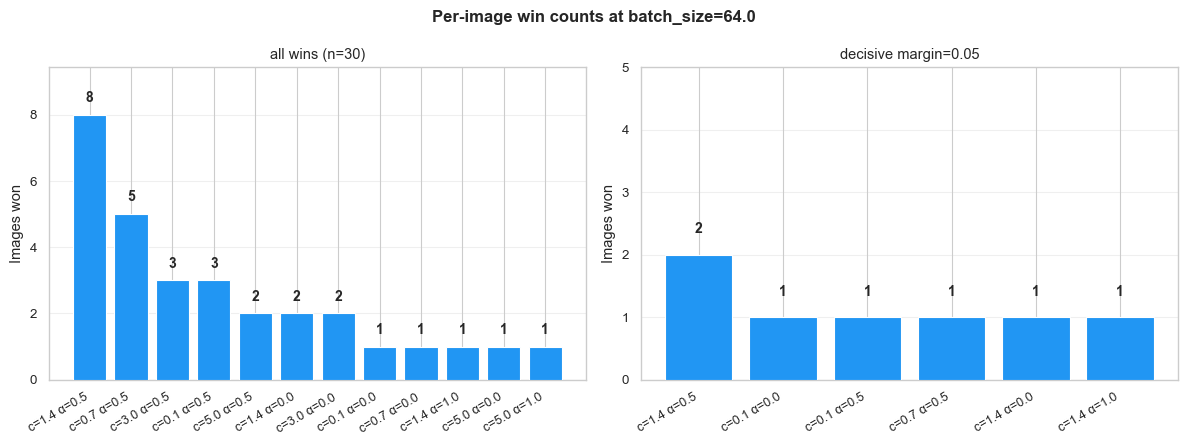

In [10]:
_top_n = child_runs_n[child_runs_n["batch_size"] == max_bs].copy()
_wins_no_top = _count_wins_ucb(_top_n, 0.0)
_wins_mg_top = _count_wins_ucb(_top_n, WIN_MARGIN)


def _cfg_label_ucb(row):
    return f"c={row['ucb_c']} ÃŽÂ±={row['ucb_alpha']}"


_n_top_img = _top_n["image_name"].nunique()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(
    f"Per-image win counts at batch_size={max_bs}", fontsize=12, fontweight="bold"
)

for ax, wins_df, title in [
    (ax1, _wins_no_top, f"all wins (n={_n_top_img})"),
    (ax2, _wins_mg_top, f"decisive margin={WIN_MARGIN}"),
]:
    if wins_df.empty:
        ax.text(0.5, 0.5, "no wins", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        continue
    wdf = wins_df.copy()
    wdf["label"] = wdf.apply(_cfg_label_ucb, axis=1)
    wdf = wdf.sort_values("wins", ascending=False).reset_index(drop=True)
    x = np.arange(len(wdf))
    ax.bar(x, wdf["wins"], color="#2196F3", zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(wdf["label"], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Images won")
    ax.set_title(title)
    ax.set_ylim(0, max(wdf["wins"].max() * 1.18, 5))
    for i, v in enumerate(wdf["wins"]):
        ax.text(
            i, v + 0.3, str(v), ha="center", va="bottom", fontsize=10, fontweight="bold"
        )
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()